In [1]:
import pandas as pd

spotify = pd.read_csv("spotify_merged_clean.csv")

In [2]:
musical_feature_columns = [
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Standardize the continuous musical features directly inside the main dataset.
# Treat key as categorical because pitch classes are not numeric in a linear sense.
continuous_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

spotify[continuous_features] = StandardScaler().fit_transform(spotify[continuous_features])

# Define the dataset without key and mode for clustering purposes, as they are categorical features.
spotify_no_key_mode = spotify.copy()
spotify_no_key_mode = spotify_no_key_mode.drop(columns=['key', 'mode'])

encoder_kwargs = {"handle_unknown": "ignore", "drop": None}
try:
    key_encoder = OneHotEncoder(sparse_output=False, **encoder_kwargs)
except TypeError:
    key_encoder = OneHotEncoder(sparse=False, **encoder_kwargs)

key_encoded = key_encoder.fit_transform(spotify[['key']])
key_encoded_columns = [f'key_{category}' for category in key_encoder.categories_[0]]
key_encoded = pd.DataFrame(key_encoded, columns=key_encoded_columns, index=spotify.index)

spotify = pd.concat([spotify.drop(columns=['key']), key_encoded], axis=1)

# If you want a clustering input table, it can now be taken directly from spotify.
X_for_clustering_no_key_mode = spotify_no_key_mode[continuous_features].copy()
X_for_clustering = spotify[continuous_features + key_encoded_columns + ['mode']].copy()

spotify[continuous_features + key_encoded_columns + ['mode']]

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key_0.0,...,key_3.0,key_4.0,key_5.0,key_6.0,key_7.0,key_8.0,key_9.0,key_10.0,key_11.0,mode
0,1.868896,-1.123959,-0.335257,0.919773,-0.678968,-0.512296,-0.311653,-0.160929,-0.605689,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.592912,-0.364169,-1.029071,-0.417897,-0.909587,0.052991,-0.538150,-1.418237,-0.063065,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.553037,0.493659,0.944242,0.840984,-0.732788,-0.521856,-0.688270,1.418466,1.355952,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.358380,-0.891120,-1.098452,-0.567597,-0.910132,1.764826,-0.640337,-0.929284,0.276147,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570126,-1.013667,-0.380699,-0.615746,-0.050149,-0.484697,-0.655612,0.359068,-0.842090,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106003,0.382146,0.755092,-0.657008,-0.474801,-0.084172,2.438127,-0.609786,-1.255252,0.107221,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
106004,2.170802,-0.188518,0.399132,0.753440,-0.704950,-0.521837,0.004389,0.673395,0.276793,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
106005,-0.705858,-0.445867,0.351863,-0.585981,1.298427,-0.520496,-0.517080,0.712201,0.692663,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
106006,-1.816647,1.257534,0.264629,-0.037081,-0.913043,-0.501847,0.868237,-1.045701,1.737234,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_for_clustering)
X_pca_no_key_mode = pca.fit_transform(X_for_clustering_no_key_mode)

In [39]:
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_for_clustering)

print(f"Original dimensions: {X_for_clustering.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

Original dimensions: 22
Reduced dimensions: 14
Explained variance: 0.953


In [40]:
X_pca_no_key_mode = pca.fit_transform(X_for_clustering_no_key_mode)

print(f"Original dimensions: {X_for_clustering_no_key_mode.shape[1]}")
print(f"Reduced dimensions: {X_pca_no_key_mode.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

Original dimensions: 9
Reduced dimensions: 8
Explained variance: 0.983


In [16]:
import time
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


def evaluate_kmeans_range(
    X,
    k_values=range(2, 16),
    random_state=42,
    n_init=10,
):
    """
    Evaluate KMeans over multiple values of k.

    Parameters
    ----------
    X : array-like
        Standardized feature matrix.
    k_values : iterable
        Values of k to evaluate.
    random_state : int
    n_init : int

    Returns
    -------
    pandas.DataFrame
        One row per k with all evaluation metrics.
    """

    results = []
    models = {}

    for k in k_values:

        start = time.perf_counter()

        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init
        )

        labels = model.fit_predict(X)

        elapsed = time.perf_counter() - start

        results.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels, sample_size=10000),
            # "calinski_harabasz": calinski_harabasz_score(X, labels),
            # "davies_bouldin": davies_bouldin_score(X, labels),
            "time_sec": elapsed
        })
    
        models[k] = model
        elapsed = time.perf_counter() - start

        print(f"Evaluated k={k} in {elapsed:.2f} seconds.")
    results_df = pd.DataFrame(results)
    
    return results_df, models

In [41]:
# Full dataset with all features, including key and mode, for clustering.
results_audio, models_audio = evaluate_kmeans_range(X_for_clustering)

# Full dataset with all features, including key and mode, for clustering. - PCA
results_pca, models_pca = evaluate_kmeans_range(X_pca)

# Dataset without key and mode for clustering.
results_audio_no_key_mode, models_audio_no_key_mode = evaluate_kmeans_range(X_for_clustering_no_key_mode)

# Dataset without key and mode for clustering. - PCA
results_audio_no_key_mode_pca, models_audio_no_key_mode_pca = evaluate_kmeans_range(X_pca_no_key_mode)


Evaluated k=2 in 0.90 seconds.
Evaluated k=3 in 0.95 seconds.
Evaluated k=4 in 0.90 seconds.
Evaluated k=5 in 0.93 seconds.
Evaluated k=6 in 0.94 seconds.
Evaluated k=7 in 1.02 seconds.
Evaluated k=8 in 1.19 seconds.
Evaluated k=9 in 1.18 seconds.
Evaluated k=10 in 1.19 seconds.
Evaluated k=11 in 1.31 seconds.
Evaluated k=12 in 1.35 seconds.
Evaluated k=13 in 1.33 seconds.
Evaluated k=14 in 1.30 seconds.
Evaluated k=15 in 1.32 seconds.
Evaluated k=2 in 0.88 seconds.
Evaluated k=3 in 0.92 seconds.
Evaluated k=4 in 0.87 seconds.
Evaluated k=5 in 0.90 seconds.
Evaluated k=6 in 0.93 seconds.
Evaluated k=7 in 0.98 seconds.
Evaluated k=8 in 1.08 seconds.
Evaluated k=9 in 1.10 seconds.
Evaluated k=10 in 1.14 seconds.
Evaluated k=11 in 1.16 seconds.
Evaluated k=12 in 1.19 seconds.
Evaluated k=13 in 1.15 seconds.
Evaluated k=14 in 1.33 seconds.
Evaluated k=15 in 1.33 seconds.
Evaluated k=2 in 0.99 seconds.
Evaluated k=3 in 0.90 seconds.
Evaluated k=4 in 0.86 seconds.
Evaluated k=5 in 0.88 secon

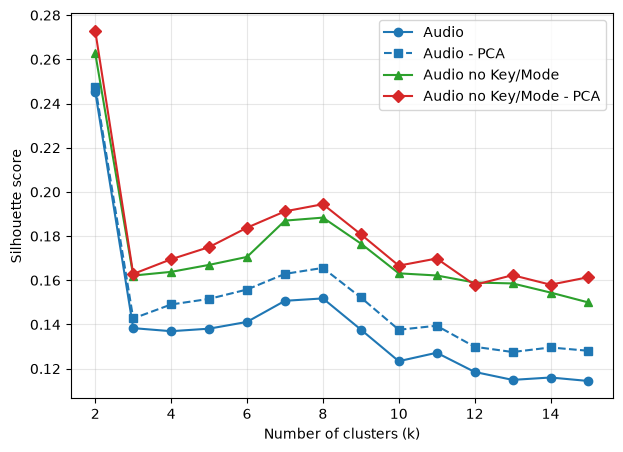

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    results_audio["k"],
    results_audio["silhouette"],
    color="tab:blue",  linestyle="-",  marker="o", label="Audio"
)

plt.plot(
    results_pca["k"],
    results_pca["silhouette"],
    color="tab:blue",  linestyle="--", marker="s", label="Audio - PCA"
)

plt.plot(
    results_audio_no_key_mode["k"],
    results_audio_no_key_mode["silhouette"],
    color="tab:green", linestyle="-",  marker="^", label="Audio no Key/Mode"
)

plt.plot(
    results_audio_no_key_mode_pca["k"],
    results_audio_no_key_mode_pca["silhouette"],
    color="tab:red", linestyle="-",  marker="D", label="Audio no Key/Mode - PCA"
)


plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

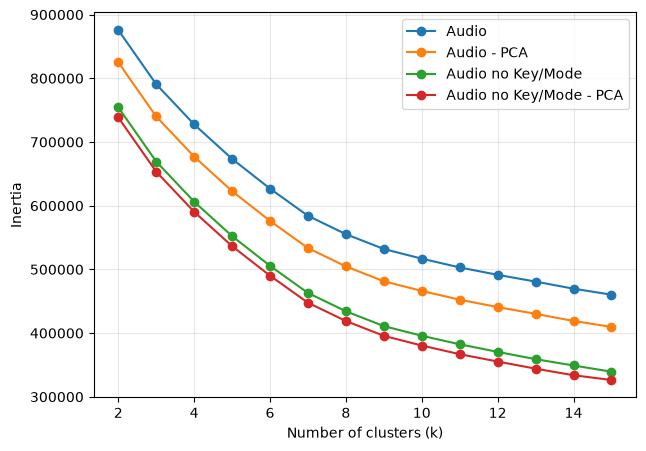

In [47]:
plt.figure(figsize=(7,5))

plt.plot(
    results_audio["k"],
    results_audio["inertia"],
    marker="o",
    label="Audio"
)

plt.plot(
    results_pca["k"],
    results_pca["inertia"],
    marker="o",
    label="Audio - PCA"
)

plt.plot(
    results_audio_no_key_mode["k"],
    results_audio_no_key_mode["inertia"],
    marker="o",
    label="Audio no Key/Mode"
)

plt.plot(
    results_audio_no_key_mode_pca["k"],
    results_audio_no_key_mode_pca["inertia"],
    marker="o",
    label="Audio no Key/Mode - PCA"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [50]:
import time
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)


def evaluate_kmeans_range(
    X,
    k_values=range(2, 16),
    random_state=42,
    n_init=10,
):
    """
    Evaluate KMeans over multiple values of k.

    Parameters
    ----------
    X : array-like
        Standardized feature matrix.
    k_values : iterable
        Values of k to evaluate.
    random_state : int
    n_init : int

    Returns
    -------
    pandas.DataFrame
        One row per k with all evaluation metrics.
    """

    results = []
    models = {}

    for k in k_values:

        start = time.perf_counter()

        model = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=n_init
        )

        labels = model.fit_predict(X)

        elapsed = time.perf_counter() - start

        results.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X, labels, sample_size=20000),
            # "calinski_harabasz": calinski_harabasz_score(X, labels),
            # "davies_bouldin": davies_bouldin_score(X, labels),
            "time_sec": elapsed
        })
    
        models[k] = model
        elapsed = time.perf_counter() - start

        print(f"Evaluated k={k} in {elapsed:.2f} seconds.")
    results_df = pd.DataFrame(results)
    
    return results_df, models

In [51]:
# Full dataset with all features, including key and mode, for clustering.
results_audio_larger, models_audio_larger = evaluate_kmeans_range(X_for_clustering)

# Full dataset with all features, including key and mode, for clustering. - PCA
results_pca_larger, models_pca_larger = evaluate_kmeans_range(X_pca)

# Dataset without key and mode for clustering.
results_audio_no_key_mode_larger, models_audio_no_key_mode_larger = evaluate_kmeans_range(X_for_clustering_no_key_mode)

# Dataset without key and mode for clustering. - PCA
results_audio_no_key_mode_pca_larger, models_audio_no_key_mode_pca_larger = evaluate_kmeans_range(X_pca_no_key_mode)


Evaluated k=2 in 2.96 seconds.
Evaluated k=3 in 2.87 seconds.
Evaluated k=4 in 2.76 seconds.
Evaluated k=5 in 2.81 seconds.
Evaluated k=6 in 2.75 seconds.
Evaluated k=7 in 2.75 seconds.
Evaluated k=8 in 2.85 seconds.
Evaluated k=9 in 3.05 seconds.
Evaluated k=10 in 2.79 seconds.
Evaluated k=11 in 2.93 seconds.
Evaluated k=12 in 2.99 seconds.
Evaluated k=13 in 3.35 seconds.
Evaluated k=14 in 2.89 seconds.
Evaluated k=15 in 2.89 seconds.
Evaluated k=2 in 2.98 seconds.
Evaluated k=3 in 2.73 seconds.
Evaluated k=4 in 2.82 seconds.
Evaluated k=5 in 2.67 seconds.
Evaluated k=6 in 2.70 seconds.
Evaluated k=7 in 2.81 seconds.
Evaluated k=8 in 2.87 seconds.
Evaluated k=9 in 2.95 seconds.
Evaluated k=10 in 2.85 seconds.
Evaluated k=11 in 2.80 seconds.
Evaluated k=12 in 2.91 seconds.
Evaluated k=13 in 3.02 seconds.
Evaluated k=14 in 3.13 seconds.
Evaluated k=15 in 2.95 seconds.
Evaluated k=2 in 2.99 seconds.
Evaluated k=3 in 2.71 seconds.
Evaluated k=4 in 2.61 seconds.
Evaluated k=5 in 2.58 secon

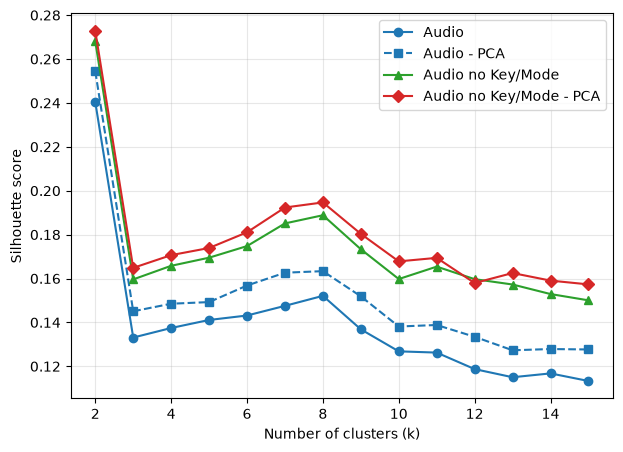

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    results_audio_larger["k"],
    results_audio_larger["silhouette"],
    color="tab:blue",  linestyle="-",  marker="o", label="Audio"
)

plt.plot(
    results_pca_larger["k"],
    results_pca_larger["silhouette"],
    color="tab:blue",  linestyle="--", marker="s", label="Audio - PCA"
)

plt.plot(
    results_audio_no_key_mode_larger["k"],
    results_audio_no_key_mode_larger["silhouette"],
    color="tab:green", linestyle="-",  marker="^", label="Audio no Key/Mode"
)

plt.plot(
    results_audio_no_key_mode_pca_larger["k"],
    results_audio_no_key_mode_pca_larger["silhouette"],
    color="tab:red", linestyle="-",  marker="D", label="Audio no Key/Mode - PCA"
)


plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

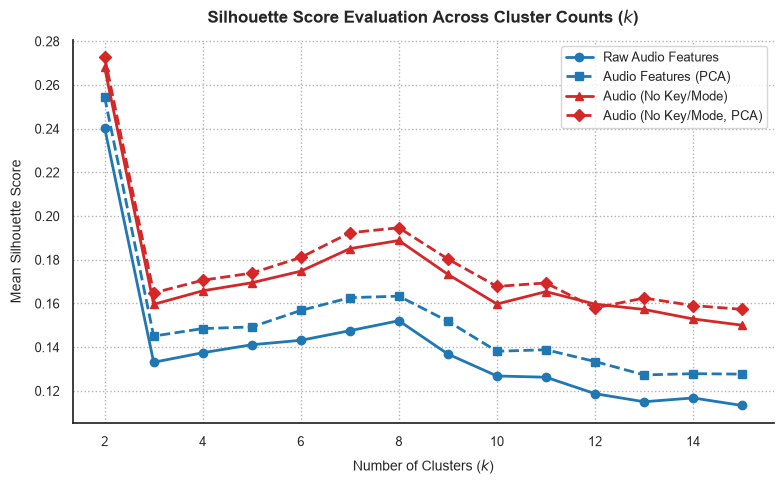

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style defaults
sns.set_theme(style="white", palette="muted")

fig, ax = plt.subplots(figsize=(8, 5))

# High-contrast, cohesive color choices
# Solid vs. dashed lines differentiate standard feature space from PCA spaces
ax.plot(
    results_audio_larger["k"],
    results_audio_larger["silhouette"],
    color="#1f77b4",
    linestyle="-",
    linewidth=2,
    marker="o",
    markersize=6,
    label="Raw Audio Features",
)

ax.plot(
    results_pca_larger["k"],
    results_pca_larger["silhouette"],
    color="#1f77b4",
    linestyle="--",
    linewidth=2,
    marker="s",
    markersize=6,
    label="Audio Features (PCA)",
)

ax.plot(
    results_audio_no_key_mode_larger["k"],
    results_audio_no_key_mode_larger["silhouette"],
    color="#d62728",
    linestyle="-",
    linewidth=2,
    marker="^",
    markersize=6,
    label="Audio (No Key/Mode)",
)

ax.plot(
    results_audio_no_key_mode_pca_larger["k"],
    results_audio_no_key_mode_pca_larger["silhouette"],
    color="#d62728",
    linestyle="--",
    linewidth=2,
    marker="D",
    markersize=6,
    label="Audio (No Key/Mode, PCA)",
)

# Axis Titles and Formatting
ax.set_title(
    "Silhouette Score Evaluation Across Cluster Counts ($k$)",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Number of Clusters ($k$)", fontsize=10, labelpad=8)
ax.set_ylabel("Mean Silhouette Score", fontsize=10, labelpad=8)

# Grid and Spacing
ax.grid(axis="both", linestyle=":", alpha=0.6, color="gray")
ax.set_axisbelow(True)

# Ticks
ax.tick_params(axis="both", which="major", labelsize=9.5)

# Clean borders (Despine top/right)
sns.despine(ax=ax)

# Legend positioning
ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    fontsize=9.5,
    loc="best",
)

plt.tight_layout()
plt.savefig("silhouette_scores_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
# print shiloutte score for each k for the dataset without key and mode for clustering and PCA.
for i in range(len(results_audio_no_key_mode_larger)):
    print(f"k={results_audio_no_key_mode_larger['k'][i]}: {results_audio_no_key_mode_larger['silhouette'][i]:.4f}, PCA={results_audio_no_key_mode_pca_larger['silhouette'][i]:.4f}")

k=2: 0.2680, PCA=0.2728
k=3: 0.1596, PCA=0.1648
k=4: 0.1658, PCA=0.1707
k=5: 0.1695, PCA=0.1739
k=6: 0.1748, PCA=0.1811
k=7: 0.1851, PCA=0.1924
k=8: 0.1888, PCA=0.1947
k=9: 0.1733, PCA=0.1803
k=10: 0.1598, PCA=0.1678
k=11: 0.1654, PCA=0.1694
k=12: 0.1597, PCA=0.1580
k=13: 0.1573, PCA=0.1625
k=14: 0.1529, PCA=0.1590
k=15: 0.1501, PCA=0.1573


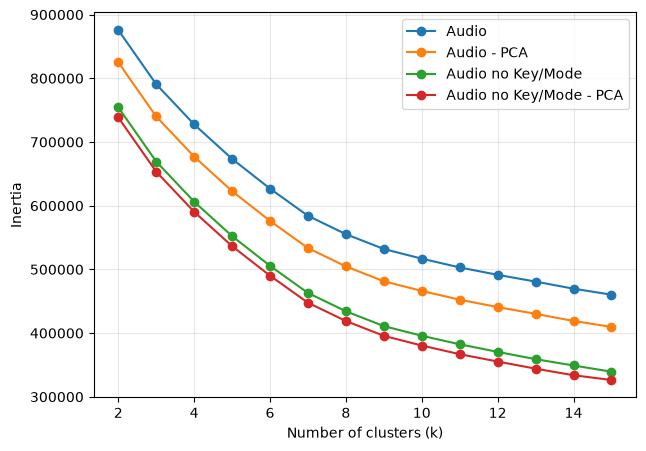

In [54]:
plt.figure(figsize=(7,5))

plt.plot(
    results_audio_larger["k"],
    results_audio_larger["inertia"],
    marker="o",
    label="Audio"
)

plt.plot(
    results_pca_larger["k"],
    results_pca_larger["inertia"],
    marker="o",
    label="Audio - PCA"
)

plt.plot(
    results_audio_no_key_mode_larger["k"],
    results_audio_no_key_mode_larger["inertia"],
    marker="o",
    label="Audio no Key/Mode"
)

plt.plot(
    results_audio_no_key_mode_pca_larger["k"],
    results_audio_no_key_mode_pca_larger["inertia"],
    marker="o",
    label="Audio no Key/Mode - PCA"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [65]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_for_clustering_no_key_mode.columns
)

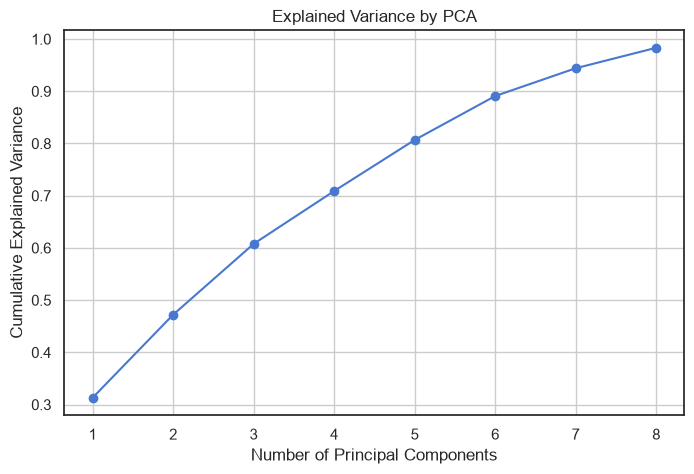

In [67]:
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cum_explained)+1),
    cum_explained,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA")

plt.grid(True)

plt.show()

In [68]:
display(loadings)

,0,1,2,3,4,5,6,7
danceability,0.253995,0.564682,-0.143002,-0.249104,0.265659,0.166107,0.627661,0.109884
energy,0.508426,-0.286040,0.010743,-0.175680,-0.010534,0.074659,-0.260896,0.172531
loudness,0.518883,-0.094263,-0.040143,-0.021306,-0.180716,-0.171977,0.017989,0.613264
speechiness,0.103225,0.127855,0.620677,-0.184337,0.595141,-0.383080,-0.206591,-0.039585
acousticness,-0.441019,0.293679,0.198713,0.315383,-0.030096,0.019448,-0.109621,0.694220
instrumentalness,-0.279726,-0.310383,-0.211432,-0.433146,0.459052,0.498472,-0.148980,0.273818
liveness,0.075919,-0.212743,0.696922,0.057889,-0.225641,0.549392,0.317875,-0.032623
valence,0.289683,0.515600,-0.032473,0.204871,0.013820,0.483044,-0.568307,-0.149943
tempo,0.186201,-0.283540,-0.147099,0.735013,0.528890,0.080578,0.191683,-0.005827


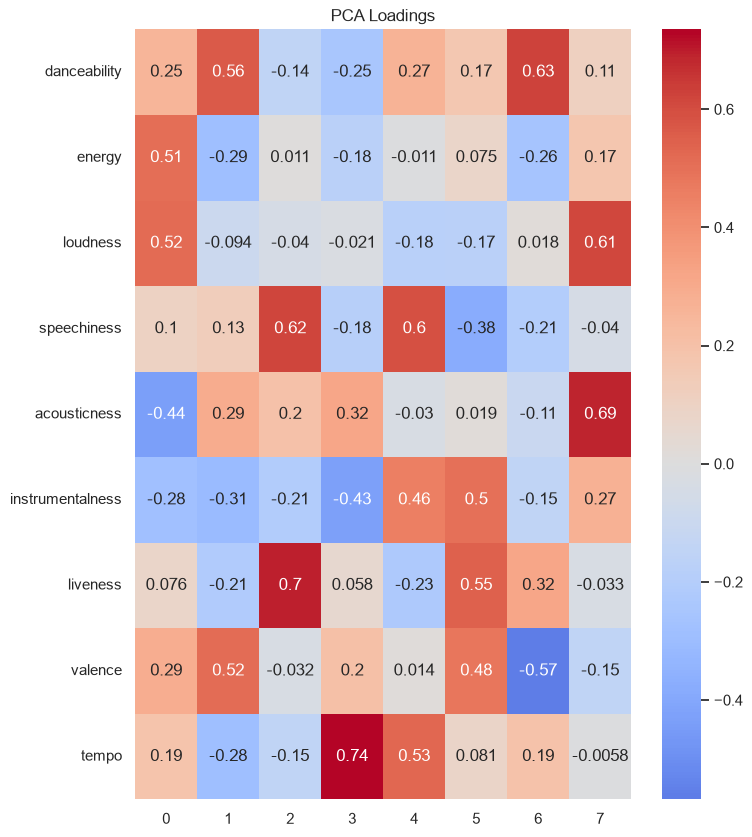

In [70]:
plt.figure(figsize=(8,10))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings")
plt.show()